# Hyperparameter Tuning

*How should LightGBM be configured?* This notebook loads the 50-trial Optuna study — run only after the feature set was frozen — and confirms the tuned pipeline's registration as MLflow `challenger`.

The study itself lives in `src/telco_churn/models/train.py`'s `run_tuning_step` and already ran (via `python -m telco_churn.models.train`), logging the parent `tuning_study` run plus 50 lightweight nested trial runs. This notebook loads that study from MLflow and renders the optimization history, hyperparameter importance, the 1-SE selection rationale, the default-vs-tuned PR-AUC comparison, the full-to-reduced-to-tuned bias/variance progression, and confirms the `challenger` registration.

In [1]:
%matplotlib inline

from __future__ import annotations

import base64
import json
import warnings
from io import BytesIO

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import HTML, Image, display
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    learning_curve,
    train_test_split,
)

load_dotenv()

import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

from telco_churn.data.split import partition
from telco_churn.features.build import FEATURE_SCHEMA, TARGET_COL
from telco_churn.features.preprocessing import build_preprocessor
from telco_churn.models.diagnostics import generalization_gap, learning_curve_points
from telco_churn.models.train.common import lgbm_default_params
from telco_churn.utils.logging import configure_logging
from telco_churn.utils.paths import compose_config, get_project_root

optuna.logging.set_verbosity(optuna.logging.WARNING)
configure_logging()
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1. Load the Optuna study from MLflow

### Connect and locate the latest run set

Every run below was produced by `python -m telco_churn.models.train` (or `make train`, once the DVC pipeline wraps this stage). `tuning_study` is resolved from whichever run is currently registered as MLflow `challenger` — not simply the most recent run named `tuning_study` — so an unregistered ad hoc run (e.g. a tuning experiment that deliberately skips registration) can never get silently picked up here. `feature_selection` has no registry alias of its own, so it's still pulled as the **most recent** run with that name; since every step is fully deterministic (fixed `random_state=42`, `deterministic=True` LightGBM, sealed data), re-running the full pipeline reproduces byte-identical results, so "latest" stays self-consistent for it — the next cell's cross-check confirms the two runs didn't drift apart from each other.

In [2]:
cfg = compose_config()

tracking_uri = str(cfg.mlflow.tracking_uri)
if "://" not in tracking_uri:
    tracking_uri = str(get_project_root() / tracking_uri)
mlflow.set_tracking_uri(tracking_uri)

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(cfg.mlflow.experiment_name)
# lifecycle_stage check is required: the MLflow UI hides deleted experiments,
# but get_experiment_by_name still returns them for reads.
if exp is None or exp.lifecycle_stage != "active":
    raise RuntimeError(
        f"No active MLflow experiment named '{cfg.mlflow.experiment_name}' found "
        f"(tracking_uri={tracking_uri}). Run `python -m telco_churn.models.train` first."
    )


def latest_run(run_name: str):
    runs = client.search_runs(
        [exp.experiment_id],
        filter_string=f"attributes.run_name = '{run_name}'",
        order_by=["start_time DESC"],
        max_results=1,
    )
    if not runs:
        raise RuntimeError(
            f"No '{run_name}' run found in experiment '{cfg.mlflow.experiment_name}'. "
            "Run `python -m telco_churn.models.train` first."
        )
    return runs[0]


registered_name = str(cfg.mlflow.registered_model_name)
try:
    tuning_study_run_id = client.get_model_version_by_alias(registered_name, "challenger").run_id
except Exception as e:
    raise RuntimeError(
        f"No 'challenger' alias found on registered model '{registered_name}'. "
        "Run `python -m telco_churn.models.train` first."
    ) from e

run_ids = {
    "feature_selection": latest_run("feature_selection").info.run_id,
    "tuning_study": tuning_study_run_id,
}
for name, run_id in run_ids.items():
    print(f"{name:<18} {run_id}")

parent_run_id = run_ids["tuning_study"]

feature_selection  f50522bd6f9340239f7e0a07285d2ac6
tuning_study       29dd80a08871449796c52bd9923c4a94


### Validate: `tuning_study` was built on this `feature_selection` run

`run_tuning_step` takes `committed_features` as an in-process argument rather than re-reading MLflow, so the feature set the Optuna study actually tuned on only matches the `feature_selection` run above if both came from the same `python -m telco_churn.models.train` execution — pulling "latest" of each independently doesn't guarantee that. Cross-check `git_sha`, `dvc_data_hash`, and the committed feature count before trusting the pairing used below.

In [3]:
feature_selection_run = client.get_run(run_ids["feature_selection"])
tuning_run = client.get_run(run_ids["tuning_study"])

assert feature_selection_run.data.tags["git_sha"] == tuning_run.data.tags["git_sha"], (
    "feature_selection and tuning_study runs come from different git commits - "
    "'latest' pulled a stale pairing across the two run names."
)
assert feature_selection_run.data.tags["dvc_data_hash"] == tuning_run.data.tags["dvc_data_hash"], (
    "feature_selection and tuning_study runs were trained on different data snapshots."
)

n_committed_selection = int(feature_selection_run.data.params["n_committed_features"])
n_committed_tuning = int(tuning_run.data.params["n_committed_features"])
assert n_committed_selection == n_committed_tuning, (
    f"feature_selection committed {n_committed_selection} features but tuning_study "
    f"was tuned on {n_committed_tuning} - the tuning run is stale against the current "
    "feature-selection freeze and needs a re-run via `python -m telco_churn.models.train`."
)

print(
    f"Confirmed: tuning_study was built on this feature_selection run "
    f"(git_sha={feature_selection_run.data.tags['git_sha'][:8]}, "
    f"{n_committed_selection} committed features)"
)

Confirmed: tuning_study was built on this feature_selection run (git_sha=f3ca0641, 20 committed features)


### Trial history

Every completed and pruned trial from the study, logged as a nested MLflow run under the `tuning_study` parent — reconstructed here from `cv_pr_auc_mean` and the trial's sampled params. A trial is **pruned** when `MedianPruner` finds it behind the running median mid-CV and kills it before the remaining folds — distinct from the per-fold early stopping (`early_stopping_rounds=50`), which still runs regardless of pruning.

In [4]:
child_runs = client.search_runs(
    [exp.experiment_id],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
    max_results=200,
)
print(f"{len(child_runs)} trial child runs")

trial_rows = []
for r in child_runs:
    number = int(r.info.run_name.split("_")[1])
    pruned = r.data.tags.get("pruned") == "true"
    row = {"number": number, "pruned": pruned, "value": r.data.metrics.get("cv_pr_auc_mean"), "run_id": r.info.run_id}
    row.update(r.data.params)
    trial_rows.append(row)
trials_df = pd.DataFrame(trial_rows).sort_values("number").reset_index(drop=True)
n_completed = int((~trials_df["pruned"]).sum())
print(f"{n_completed} completed, {len(trials_df) - n_completed} pruned")

50 trial child runs


16 completed, 34 pruned


All 50 requested trials ran — none were skipped by the 90-minute `timeout_seconds` cap — but only 16 survived every fold to report a real `cv_pr_auc_mean`; `MedianPruner` cut the other 34 short once they fell behind the running median at some fold. 16 completed still clears `min_completed_trials=10` (`configs/tuning/optuna.yaml`), so §4's 1-SE selection below is drawn from enough finished trials to trust rather than one flagged as unreliable.

## 2. Optimization history

Did the search actually settle on a good configuration, or was it still improving when the trial budget ran out? The scatter is every completed trial's CV PR-AUC; the line is the running best — a plateau says the search had converged, while a still-climbing line would say more trials could plausibly help.

Logged directly by `run_tuning_step` as a run artifact and displayed here from MLflow, not regenerated.

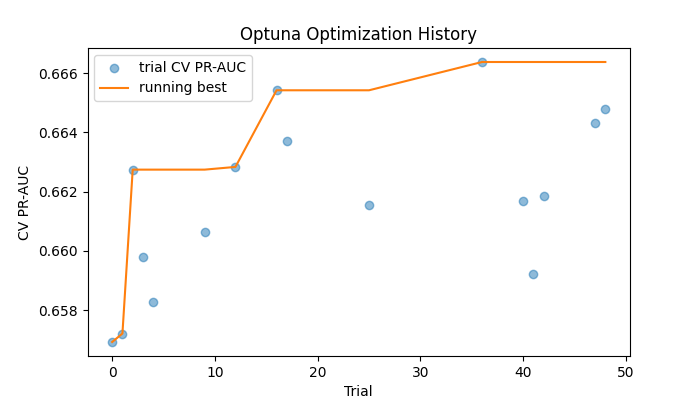

Best trial: 37 of 50, PR-AUC 0.6664 — running best last improved here, not still climbing at the budget cap.


In [5]:
opt_hist_path = mlflow.artifacts.download_artifacts(run_id=parent_run_id, artifact_path="tuning/optimization_history.png")
display(Image(filename=opt_hist_path))

completed = trials_df[~trials_df["pruned"]].copy()
raw_best_trial = int(completed.loc[completed["value"].idxmax(), "number"]) + 1
n_trials_requested = int(trials_df["number"].max()) + 1
print(f"Best trial: {raw_best_trial} of {n_trials_requested}, PR-AUC {completed['value'].max():.4f} — running best last improved here, not still climbing at the budget cap.")

The climb happens in three steps, clearly visible against the tight y-axis (0.657–0.666): an early jump at trial 2 (within the `n_startup_trials=10` random warm-up), a barely-visible tick at trial 13 followed by a clearer second step at trial 17, then a final, smaller step to the raw-best trial 37 (PR-AUC 0.6664) — with gaps between the 16 plotted points marking the 34 pruned trials. The five trials after that (40, 41, 42, 47, 48) all land below the running best, so the budget ended on a genuine plateau, not a cutoff.

## 3. Hyperparameter importance

Which hyperparameters actually drove the CV PR-AUC differences across completed trials, and which barely mattered? **fANOVA importance** attributes that variation per hyperparameter, so future search-range widening can focus on what actually moves the needle.

fANOVA needs each trial's parameter *distributions*, not just its value, so the `optuna.Study` below is reconstructed from MLflow-logged trial params rather than loaded from the real Postgres-persisted study — keeping this notebook dependent only on the MLflow tracking URI, like `03a`/`03b`.

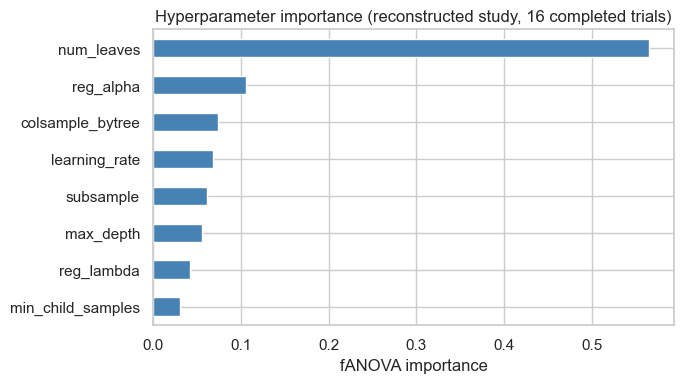

In [6]:
search_space_cfg = cfg.tuning.search_space
distributions = {}
for name, spec in search_space_cfg.items():
    name = str(name)
    if str(spec.type) == "int":
        distributions[name] = optuna.distributions.IntDistribution(int(spec.low), int(spec.high))
    else:
        distributions[name] = optuna.distributions.FloatDistribution(
            float(spec.low), float(spec.high), log=bool(spec.get("log", False))
        )

study = optuna.create_study(direction="maximize")
optuna_trials = []
for _, row in completed.iterrows():
    params = {name: float(row[name]) if not isinstance(distributions[name], optuna.distributions.IntDistribution) else int(float(row[name])) for name in distributions}
    optuna_trials.append(
        optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(row["value"]),
            state=optuna.trial.TrialState.COMPLETE,
        )
    )
study.add_trials(optuna_trials)

importances = optuna.importance.get_param_importances(study)
imp_df = pd.Series(importances, name="importance").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
imp_df.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("fANOVA importance")
ax.set_title(f"Hyperparameter importance (reconstructed study, {len(completed)} completed trials)")
plt.tight_layout()
plt.show()

`num_leaves` dominates by a wide margin — roughly half of total importance, several times the next-highest hyperparameter — exactly what LightGBM's leaf-wise-growth behavior would predict, since `num_leaves` is its main complexity control (`tuning.py`'s `select_best_trial` docstring cites this structurally, independent of any single study's own fANOVA ranking). **The ordering of the remaining seven hyperparameters below `num_leaves` is not guaranteed reproducible**: Optuna's fANOVA evaluator (`FanovaImportanceEvaluator`) has no fixed `seed`, so its internal random-forest surrogate can reshuffle the second-through-eighth ranks between runs — only `num_leaves`'s dominance is a stable read.

## 4. Selected hyperparameters — 1-SE vs. raw-best

Two ways to read the same search: adopt the raw-best trial outright, or adopt the simplest configuration statistically indistinguishable from it. This build takes the second option — the **1-SE rule** (Breiman/glmnet convention) picks the most-regularized trial (fewest `num_leaves`) among those within one standard error of the raw-best score, not bare argmax — since a small PR-AUC edge across trials can easily be fold-to-fold noise, not worth the added complexity.

In [7]:
training_manifest_path = mlflow.artifacts.download_artifacts(run_id=parent_run_id, artifact_path="training_manifest.json")
training_manifest = json.load(open(training_manifest_path))
selected_params = training_manifest["hyperparameters"]
tuning_summary = training_manifest["tuning_summary"]

raw_best_row = completed.loc[completed["value"].idxmax()]
assert int(raw_best_row["number"]) == tuning_summary["raw_best_trial_number"], (
    "the raw-best trial reconstructed from child runs above doesn't match "
    "training_manifest.json's tuning_summary — the MLflow child-run pull is stale "
    "against the run that actually produced this manifest."
)

compare_df = pd.DataFrame(
    {
        "1-SE selected (adopted)": {k: selected_params[k] for k in distributions} | {"n_estimators": selected_params["n_estimators"], "→ CV PR-AUC": training_manifest["cv_pr_auc_mean"]},
        "raw-best (trial %d)" % (int(raw_best_row["number"]) + 1): {k: float(raw_best_row[k]) for k in distributions} | {"n_estimators": float(raw_best_row["n_estimators_median"]), "→ CV PR-AUC": float(raw_best_row["value"])},
    }
)
display(compare_df.style.format("{:.2f}").set_properties(
    subset=pd.IndexSlice[["→ CV PR-AUC"], :], **{"font-weight": "bold", "border-top": "2px solid"}
))

print(f"1-SE band: SE={tuning_summary['se']:.4f} across {int(cfg.tuning.cv_folds)} folds -> floor {tuning_summary['band_floor']:.4f} (adopted trial clears it at {float(training_manifest['cv_pr_auc_mean']):.4f})")

boundary_hits = tuning_summary["boundary_hits"]
hit_params = [k for k, v in boundary_hits.items() if v]
print(f"n_boundary_hits: {len(hit_params)}" + (f" ({', '.join(hit_params)})" if hit_params else " (none)"))

,1-SE selected (adopted),raw-best (trial 37)
num_leaves,11.00,137.00
learning_rate,0.06,0.05
min_child_samples,74.00,44.00
subsample,0.86,0.72
colsample_bytree,0.89,0.67
reg_alpha,0.74,2.39
reg_lambda,3.58,2.58
max_depth,4.00,4.00
n_estimators,59.00,102.00
→ CV PR-AUC,0.66,0.67


1-SE band: SE=0.0140 across 5 folds -> floor 0.6524 (adopted trial clears it at 0.6606)
n_boundary_hits: 0 (none)


The 1-SE pick has far fewer `num_leaves` (11 vs. 137) and about half the tree count (59 vs. 102) of the raw-best trial, for a ~0.006 PR-AUC difference (0.66 vs. 0.67 above, rounded to 2dp) — smaller than the amount the raw-best trial's own score would naturally bounce around on a different fold split (SE=0.0140, band floor 0.6524), so the two trials aren't meaningfully different in performance, just in complexity. (This isn't a coincidence: the 1-SE rule is built to only pick from trials inside that noise band in the first place.) The boundary-hit check confirms `n_boundary_hits=0` — neither `num_leaves` nor `max_depth` sits on its searched range's edge, so the search space comfortably contains the selected trial's values.

## 5. Default vs. tuned configuration

§4 compared tuned configurations against each other (1-SE vs. raw-best) — this compares the adopted 1-SE configuration against doing nothing: LightGBM's own defaults, fit on the same committed feature set. If tuning doesn't beat the default here, none of §4's search-outcome comparisons matter.

,default (untuned),"tuned (1-SE, adopted)"
num_leaves,20.00,11.00
learning_rate,0.10,0.06
min_child_samples,50.00,74.00
subsample,1.00,0.86
colsample_bytree,1.00,0.89
reg_alpha,0.00,0.74
reg_lambda,0.00,3.58
max_depth,-1.00,4.00
n_estimators,100.00,59.00

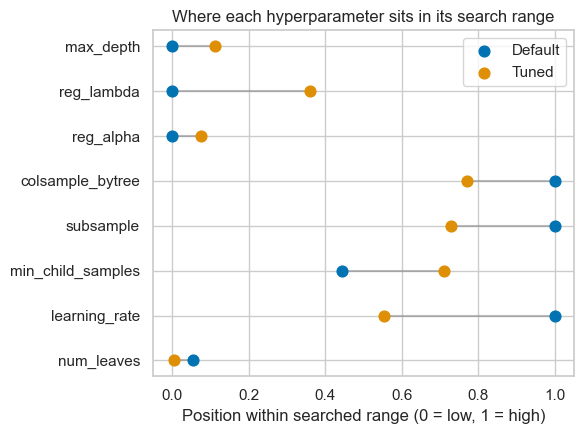


Same 20 features, default vs. tuned hyperparameters:
Default CV PR-AUC: 0.6582
Tuned CV PR-AUC:   0.6659
Improvement:       +0.0077


In [8]:
processed_path = get_project_root() / str(cfg.paths.processed_data) / "telco_churn_processed.csv"
df = pd.read_csv(processed_path)
dev_df, _test_df = partition(df)

committed_features = training_manifest["feature_columns"]
n_committed_features = len(committed_features)

random_state = int(cfg.random_seed)
cc = cfg.training_setup
default_params = lgbm_default_params(cfg, random_state)
tuned_params = {k: v for k, v in selected_params.items()}


def _binary_multi_numeric(cols: list[str]) -> tuple[list[str], list[str], list[str]]:
    return (
        [c for c in FEATURE_SCHEMA.binary if c in cols],
        [c for c in FEATURE_SCHEMA.multi_cat if c in cols],
        [c for c in FEATURE_SCHEMA.numeric if c in cols],
    )


def _cv_gap(cols: list[str], model_params: dict) -> dict:
    binary, multi_cat, numeric = _binary_multi_numeric(cols)
    X, y = dev_df[cols], dev_df[TARGET_COL]
    cv = RepeatedStratifiedKFold(n_splits=int(cc.cv_folds), n_repeats=int(cc.cv_repeats), random_state=random_state)
    train_scores, cv_scores = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        preprocessor = build_preprocessor(binary, multi_cat, numeric)
        X_tr_t = preprocessor.fit_transform(X_tr)
        X_val_t = preprocessor.transform(X_val)
        model = LGBMClassifier(**model_params)
        model.fit(X_tr_t, y_tr)
        train_scores.append(float(average_precision_score(y_tr, model.predict_proba(X_tr_t)[:, 1])))
        cv_scores.append(float(average_precision_score(y_val, model.predict_proba(X_val_t)[:, 1])))
    return generalization_gap(train_scores, cv_scores)


gap_reduced = _cv_gap(committed_features, default_params)
gap_tuned = _cv_gap(committed_features, tuned_params)

assert gap_tuned["cv_pr_auc_mean"] >= gap_reduced["cv_pr_auc_mean"], (
    f"Tuning should not regress CV PR-AUC vs. the untuned default "
    f"({gap_tuned['cv_pr_auc_mean']:.4f} < {gap_reduced['cv_pr_auc_mean']:.4f}) — "
    "the §5 narrative claims tuning improves PR-AUC; if this no longer holds, "
    "the write-up below is stale and needs revisiting."
)

default_model_params = LGBMClassifier(**default_params).get_params()
tuned_keys = list(distributions) + ["n_estimators"]

default_vs_tuned = pd.DataFrame(
    {
        "default (untuned)": {k: default_model_params[k] for k in tuned_keys},
        "tuned (1-SE, adopted)": {k: tuned_params[k] for k in tuned_keys},
    }
)

search_space_cfg = cfg.tuning.search_space
range_rows = []
for name in distributions:
    spec = search_space_cfg[name]
    low, high = float(spec.low), float(spec.high)
    default_pos = float(np.clip((default_model_params[name] - low) / (high - low), 0, 1))
    tuned_pos = float(np.clip((tuned_params[name] - low) / (high - low), 0, 1))
    range_rows.append({"param": name, "default": default_pos, "tuned": tuned_pos})
range_df = pd.DataFrame(range_rows).set_index("param")

fig, ax = plt.subplots(figsize=(6, 4.5))
y_pos = np.arange(len(range_df))
ax.hlines(y_pos, range_df["default"], range_df["tuned"], color="gray", alpha=0.5, zorder=1)
ax.scatter(range_df["default"], y_pos, color="C0", label="Default", zorder=2, s=60)
ax.scatter(range_df["tuned"], y_pos, color="C1", label="Tuned", zorder=2, s=60)
ax.set_yticks(y_pos)
ax.set_yticklabels(range_df.index)
ax.set_xlabel("Position within searched range (0 = low, 1 = high)")
ax.set_xlim(-0.05, 1.05)
ax.set_title("Where each hyperparameter sits in its search range")
ax.legend()
plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
plt.close(fig)
chart_b64 = base64.b64encode(buf.getvalue()).decode()

table_html = default_vs_tuned.style.format("{:.2f}").to_html()
display(HTML(
    '<div style="display:flex; align-items:center; gap:24px; flex-wrap:wrap;">'
    f'<div>{table_html}</div>'
    f'<div><img src="data:image/png;base64,{chart_b64}" /></div>'
    "</div>"
))

delta_pr_auc = gap_tuned["cv_pr_auc_mean"] - gap_reduced["cv_pr_auc_mean"]
print(f"\nSame {n_committed_features} features, default vs. tuned hyperparameters:")
print(f"Default CV PR-AUC: {gap_reduced['cv_pr_auc_mean']:.4f}")
print(f"Tuned CV PR-AUC:   {gap_tuned['cv_pr_auc_mean']:.4f}")
print(f"Improvement:       {delta_pr_auc:+.4f}")

Tuning wins clearly: CV PR-AUC rises from 0.6582 (default) to 0.6659 (tuned), a +0.0077 gain. The table and chart above show why — most of LightGBM's defaults sit at the edge of the searched range: `reg_alpha`/`reg_lambda` at the floor (0), `subsample`/`colsample_bytree`/`learning_rate` at the ceiling, `max_depth` unbounded entirely. Tuning pulls most of them toward the interior — except `num_leaves`, which moves the other way, from already near its floor (20) to almost on it (11): the one knob tuning pushes further toward an edge rather than away from one, consistent with §4's boundary-hit check still landing close to that floor even though it's no longer exactly on it.

## 6. Full-feature to reduced-feature to tuned bias/variance progression

Does the tuned model actually generalize better, or just relocate the same overfitting problem? Three stages — full-feature default, reduced-feature default, and tuned — are compared via `generalization_gap` on the same `RepeatedStratifiedKFold(10x10)` scheme, isolating what feature selection changed from what tuning changed.

The learning curve and early-stopping curve below use a lighter, separate CV, scoped to the tuned model only, to show *where* the remaining gap comes from.

,train_pr_auc_mean,cv_pr_auc_mean,gap_mean,gap_std
stage,,,,
"1 Full (20 features, default)",0.7943,0.6582,0.1362,0.0377
"2 Reduced (20 features, default)",0.7943,0.6582,0.1362,0.0377
"3 Tuned (20 features, 1-SE)",0.6987,0.6659,0.0328,0.0399


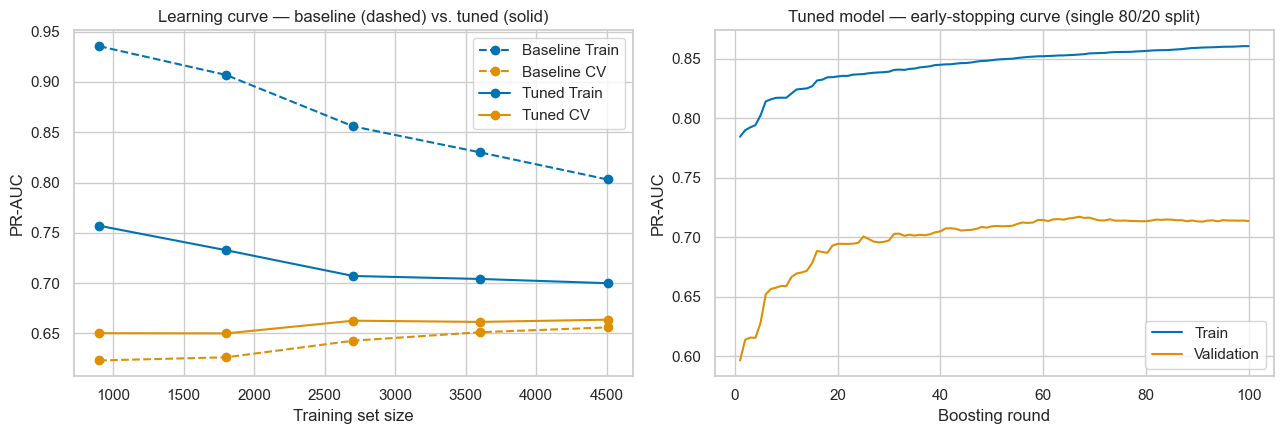

Baseline learning curve CV PR-AUC: 0.623 (20% of dev) -> 0.656 (100% of dev)
Tuned learning curve CV PR-AUC: 0.650 (20% of dev) -> 0.664 (100% of dev)
Early-stopping curve best validation PR-AUC: 0.7171 at round 67/100


In [9]:
full_features = list(FEATURE_SCHEMA.binary) + list(FEATURE_SCHEMA.multi_cat) + list(FEATURE_SCHEMA.numeric)
gap_full = _cv_gap(full_features, default_params)

assert gap_tuned["gap_mean"] < gap_reduced["gap_mean"], (
    f"Tuning should shrink the train/CV gap vs. the reduced-feature default "
    f"({gap_tuned['gap_mean']:.4f} >= {gap_reduced['gap_mean']:.4f}) — "
    "the §6 narrative claims tuning is a regularisation fix, not just a PR-AUC bump; if this "
    "no longer holds, the write-up below is stale and needs revisiting."
)

n_full_features = len(full_features)

progression = pd.DataFrame(
    [
        {"stage": f"1 Full ({n_full_features} features, default)", **gap_full},
        {"stage": f"2 Reduced ({n_committed_features} features, default)", **gap_reduced},
        {"stage": f"3 Tuned ({n_committed_features} features, 1-SE)", **gap_tuned},
    ]
).set_index("stage")
display(progression.style.format("{:.4f}"))

binary, multi_cat, numeric = _binary_multi_numeric(committed_features)
X_committed, y_committed = dev_df[committed_features], dev_df[TARGET_COL]

X_tr_dev, X_val_dev, y_tr_dev, y_val_dev = train_test_split(
    X_committed, y_committed, test_size=0.2, stratify=y_committed, random_state=random_state
)
preprocessor_es = build_preprocessor(binary, multi_cat, numeric)
X_tr_es = preprocessor_es.fit_transform(X_tr_dev)
X_val_es = preprocessor_es.transform(X_val_dev)

# n_estimators overridden to 100 rounds so the curve isn't cut off at the tuned model's own early-stopped count (61).
es_params = {**tuned_params, "n_estimators": int(default_params["n_estimators"])}
es_model = LGBMClassifier(**es_params)
es_model.fit(
    X_tr_es,
    y_tr_dev,
    eval_set=[(X_tr_es, y_tr_dev), (X_val_es, y_val_dev)],
    eval_names=["train", "val"],
    eval_metric="average_precision",
)
evals = es_model.evals_result_
rounds = np.arange(1, len(evals["train"]["average_precision"]) + 1)

lc_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=random_state)
X_committed_t = build_preprocessor(binary, multi_cat, numeric).fit_transform(X_committed)

train_sizes_abs, lc_train_scores, lc_cv_scores = learning_curve(
    LGBMClassifier(**tuned_params),
    X_committed_t,
    y_committed,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=lc_cv,
    scoring="average_precision",
    n_jobs=1,
)
lc_df = pd.DataFrame(learning_curve_points(train_sizes_abs.tolist(), lc_train_scores.tolist(), lc_cv_scores.tolist()))

baseline_train_sizes_abs, baseline_lc_train_scores, baseline_lc_cv_scores = learning_curve(
    LGBMClassifier(**default_params),
    X_committed_t,
    y_committed,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=lc_cv,
    scoring="average_precision",
    n_jobs=1,
)
baseline_lc_df = pd.DataFrame(
    learning_curve_points(
        baseline_train_sizes_abs.tolist(), baseline_lc_train_scores.tolist(), baseline_lc_cv_scores.tolist()
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(baseline_lc_df["train_size"], baseline_lc_df["train_pr_auc_mean"], marker="o", linestyle="--", color="C0", label="Baseline Train")
axes[0].plot(baseline_lc_df["train_size"], baseline_lc_df["cv_pr_auc_mean"], marker="o", linestyle="--", color="C1", label="Baseline CV")
axes[0].plot(lc_df["train_size"], lc_df["train_pr_auc_mean"], marker="o", color="C0", label="Tuned Train")
axes[0].plot(lc_df["train_size"], lc_df["cv_pr_auc_mean"], marker="o", color="C1", label="Tuned CV")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Learning curve — baseline (dashed) vs. tuned (solid)")
axes[0].legend()

axes[1].plot(rounds, evals["train"]["average_precision"], label="Train")
axes[1].plot(rounds, evals["val"]["average_precision"], label="Validation")
axes[1].set_xlabel("Boosting round")
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Tuned model — early-stopping curve (single 80/20 split)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Baseline learning curve CV PR-AUC: {baseline_lc_df['cv_pr_auc_mean'].iloc[0]:.3f} (20% of dev) -> {baseline_lc_df['cv_pr_auc_mean'].iloc[-1]:.3f} (100% of dev)")
print(f"Tuned learning curve CV PR-AUC: {lc_df['cv_pr_auc_mean'].iloc[0]:.3f} (20% of dev) -> {lc_df['cv_pr_auc_mean'].iloc[-1]:.3f} (100% of dev)")
best_round = int(np.argmax(evals["val"]["average_precision"])) + 1
best_val = max(evals["val"]["average_precision"])
print(f"Early-stopping curve best validation PR-AUC: {best_val:.4f} at round {best_round}/{len(rounds)}")

Selection (1 -> 2) shows no movement — not because feature count doesn't matter, but because this run kept all 20 features, so there's no real comparison there. Tuning (2 -> 3) is what does the work: the gap shrinks 76% (0.1362 -> 0.0328) while CV PR-AUC still improves (§5: +0.0077).

The learning curve shows this directly, on the same paired features and CV split for both lines: baseline's dashed Train/CV sit much further apart than tuned's solid ones. The early-stopping curve shows two separate signs of reduced variance: the final Train-Validation gap is smaller (~0.86 vs. ~0.71, vs. `03a`'s ~0.91 vs. ~0.70), and the divergence starts later — Validation keeps improving until round ~67 (peak 0.7171) instead of plateauing by round 20 — so more of the training budget is spent learning real signal before the model starts purely overfitting.

## 7. Challenger registration confirmation

Does the tuned model actually make it into the registry intact and reloadable, not just numbers in a report? This section confirms the log → reload → predict round-trip and captures the audit trail behind it.

The full `Pipeline` (not the bare estimator) is registered as `telco-churn-pipeline`, alias `challenger`, along with `training_manifest.json` and the feature-space audit files.

In [10]:
print(f"Model family: {training_manifest['model_family']}")
print(f"Feature space (pre-selection): {len(training_manifest['feature_space'])} columns")
print(f"Feature columns (in model)   : {len(training_manifest['feature_columns'])} columns")
print(f"Tuned model CV PR-AUC ({int(cfg.tuning.cv_folds)}-fold CV): {training_manifest['cv_pr_auc_mean']:.4f}")
print()

registered_name = str(cfg.mlflow.registered_model_name)
challenger_version = client.get_model_version_by_alias(registered_name, "challenger")
print(f"'{registered_name}' alias 'challenger' -> version {challenger_version.version} (run {challenger_version.run_id})")
assert challenger_version.run_id == parent_run_id, "challenger alias does not point at this study's run"

loaded_model = mlflow.sklearn.load_model(f"models:/{registered_name}@challenger")
sample = dev_df[committed_features].head(5)
preds = loaded_model.predict_proba(sample)[:, 1]
print(f"\nLoaded challenger predicts on a 5-row dev sample: {np.round(preds, 4).tolist()}")

Model family: lightgbm
Feature space (pre-selection): 20 columns
Feature columns (in model)   : 20 columns
Tuned model CV PR-AUC (5-fold CV): 0.6606

'telco-churn-pipeline' alias 'challenger' -> version 1 (run 29dd80a08871449796c52bd9923c4a94)



Loaded challenger predicts on a 5-row dev sample: [0.167, 0.0915, 0.1912, 0.7621, 0.7482]


The registered `challenger` loads and predicts successfully outside of the training process that created it — the log -> reload -> predict guarantee holds. **This is the raw tuned model: uncalibrated, un-thresholded, and never evaluated on the sealed test set.** Nothing downstream should serve it directly — calibration and a cost-sensitive threshold still need to be added to this same run, and it still needs to be evaluated on the sealed test once before any promotion to `champion`.

## Summary

This notebook loads the 50-trial Optuna hyperparameter study, renders the optimization history, hyperparameter importance, 1-SE selection rationale, and default-vs-tuned comparison, and confirms the tuned pipeline's registration as MLflow `challenger`. Logic lives in `run_tuning_step` (`src/telco_churn/models/train/tuning.py`), which already ran and logged every trial to MLflow; this notebook loads and renders those runs.

The 1-SE rule adopts a materially simpler configuration (`num_leaves=11`, ~59 trees) over the raw-best trial for a within-noise ~0.006 PR-AUC difference. Tuning beats doing nothing — CV PR-AUC rises from 0.6582 (default) to 0.6659 (tuned) — and is this build's primary overfit lever, shrinking the train/CV gap ~76%. The pipeline is registered as `challenger`, reload-parity confirmed, but still raw: uncalibrated and untested on the sealed test set. Full narrative: **[§4c Hyperparameter Tuning (Optuna)](../ANALYSIS.md#4c-hyperparameter-tuning-optuna)** in `ANALYSIS.md`.